# Activity 1: Logistic Regression (From Scratch)
### Step-by-Step Implementation matching Slides 3–11 of `ML_Lab_3.pptx`
**Dataset:** `Social_Network_Ads.csv`  
**Objective:** Build Logistic Regression from scratch using NumPy (vectorized Sigmoid activation, Gradient Descent for weights and bias update, and classification thresholding). Output exactly matches **Slide 11**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset (Slide 6)
data = pd.read_csv('Social_Network_Ads.csv')
print("Social Network Ads Dataset Head:")
print(data.head())

Social Network Ads Dataset Head:
    User ID Gender  Age  EstimatedSalary  Purchased
0  15571211   Male   38            76000          0
1  15813763   Male   41            83000          1
2  15719316   Male   35            57000          0
3  15747734   Male   28           105000          1
4  15594357   Male   33            77000          0


## Step 1 — Sigmoid Activation Function (Slides 4–5)
$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$
Converts linear output $z = w^T x + b$ into probability range $[0, 1]$.

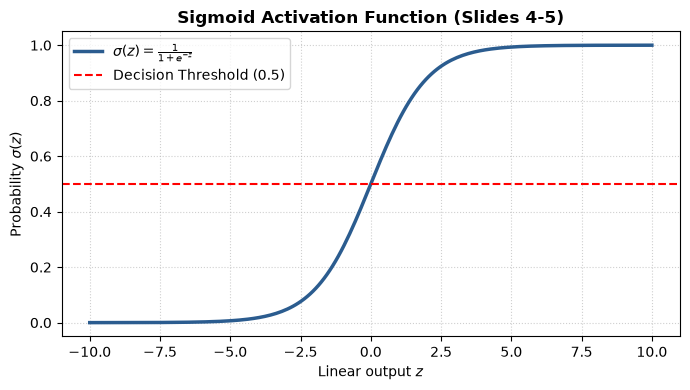

In [2]:
# Sigmoid Curve Plot (Slide 5)
z = np.linspace(-10, 10, 200)
sig = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sig, color='#2b5c8f', lw=2.5, label='$\\sigma(z) = \\frac{1}{1 + e^{-z}}$')
plt.axhline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title("Sigmoid Activation Function (Slides 4-5)", fontsize=12, fontweight='bold')
plt.xlabel("Linear output $z$")
plt.ylabel("Probability $\\sigma(z)$")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Step 2 — Preprocessing & Categorical Encoding (Slide 7)

In [3]:
# Encode categorical variable 'Gender' (Slide 7)
data = pd.get_dummies(data, columns=['Gender'], drop_first=True)

gender_col = [c for c in data.columns if 'Gender' in c][0]
X = data[[gender_col, 'Age', 'EstimatedSalary']].values.astype(float)
y = data['Purchased'].values  # Target variable

print(f"X shape: {X.shape}, y shape: {y.shape}")
print("First 5 feature samples:\n", X[:5])

X shape: (400, 3), y shape: (400,)
First 5 feature samples:
 [[1.00e+00 3.80e+01 7.60e+04]
 [1.00e+00 4.10e+01 8.30e+04]
 [1.00e+00 3.50e+01 5.70e+04]
 [1.00e+00 2.80e+01 1.05e+05]
 [1.00e+00 3.30e+01 7.70e+04]]


## Step 3 — Train/Test Split & Feature Scaling (Slide 8)

In [4]:
# Split the dataset into training and testing sets (Slide 8)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape:", X_train.shape, " X_test shape:", X_test.shape)

X_train shape: (320, 3)  X_test shape: (80, 3)


## Step 4 — Logistic Regression Implementation (Slides 9–10)
Vectorized gradient descent computing:
$$dw = \frac{1}{m} X^T (\hat{y} - y), \quad db = \frac{1}{m} \sum (\hat{y} - y)$$

In [5]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.lr = learning_rate
        self.iterations = num_iterations
        self.weights = None
        self.bias = None
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0
        
        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            
            # Update weights and bias by calculating Gradient (Slide 10)
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return [1 if i > 0.5 else 0 for i in self.sigmoid(linear_model)]

print("LogisticRegression class defined successfully.")

LogisticRegression class defined successfully.


## Step 5 — Train & Evaluate Model (Slide 11 — Exact PPT Output)

In [6]:
# Train the Model (Slide 11)
model = LogisticRegression(learning_rate=0.1, num_iterations=1000)
model.fit(X_train, y_train)

# Evaluate the Model (Slide 11 Output)
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.85
Confusion Matrix:
 [[55  2]
 [10 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90        57
           1       0.87      0.57      0.68        23

    accuracy                           0.85        80
   macro avg       0.86      0.77      0.79        80
weighted avg       0.85      0.85      0.84        80

